## Mini Project: Medical Insurance Cost Prediction sybmitted by Heramba Kakati,Batch 13

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder

# For evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# Display settings
pd.set_option('display.max_columns', None)

### 1. Import and Load the Data
   - Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn, etc.)
   - Load the dataset and explore the structure using .head(), .info() and .describe()


In [2]:
df = pd.read_csv("Health_Insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1337, 7)


**Insights:**
- The dataset was checked for duplicate records, and one duplicate row was found and removed.
After removal, the dataset contains 1337 records.

In [10]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

**Insights:**

- The dataset was examined using statistical summary and unique value analysis.

- The charges variable shows a wide range of values, with the mean greater than the median, indicating a right-skewed distribution. This suggests the presence of high-cost outliers.

- The bmi feature shows moderate variation and is approximately normally distributed, making it suitable for modeling.

- The age variable is fairly uniformly distributed across the dataset.

- The children variable is discrete and concentrated at lower values (mostly 0–2), indicating that most individuals have fewer dependents.

- The nunique analysis confirms that sex, smoker, and region are categorical variables with limited unique values, while bmi and charges are continuous numerical variables.

Overall, the dataset contains a mix of categorical and numerical features, making it suitable for regression analysis.

### 2. Exploratory Data Analysis (EDA)
- Visualize the distribution of each feature
- Understand correlations (especially with the target variable)
- Check for variables distributions.
- Summarize Insights from EDA


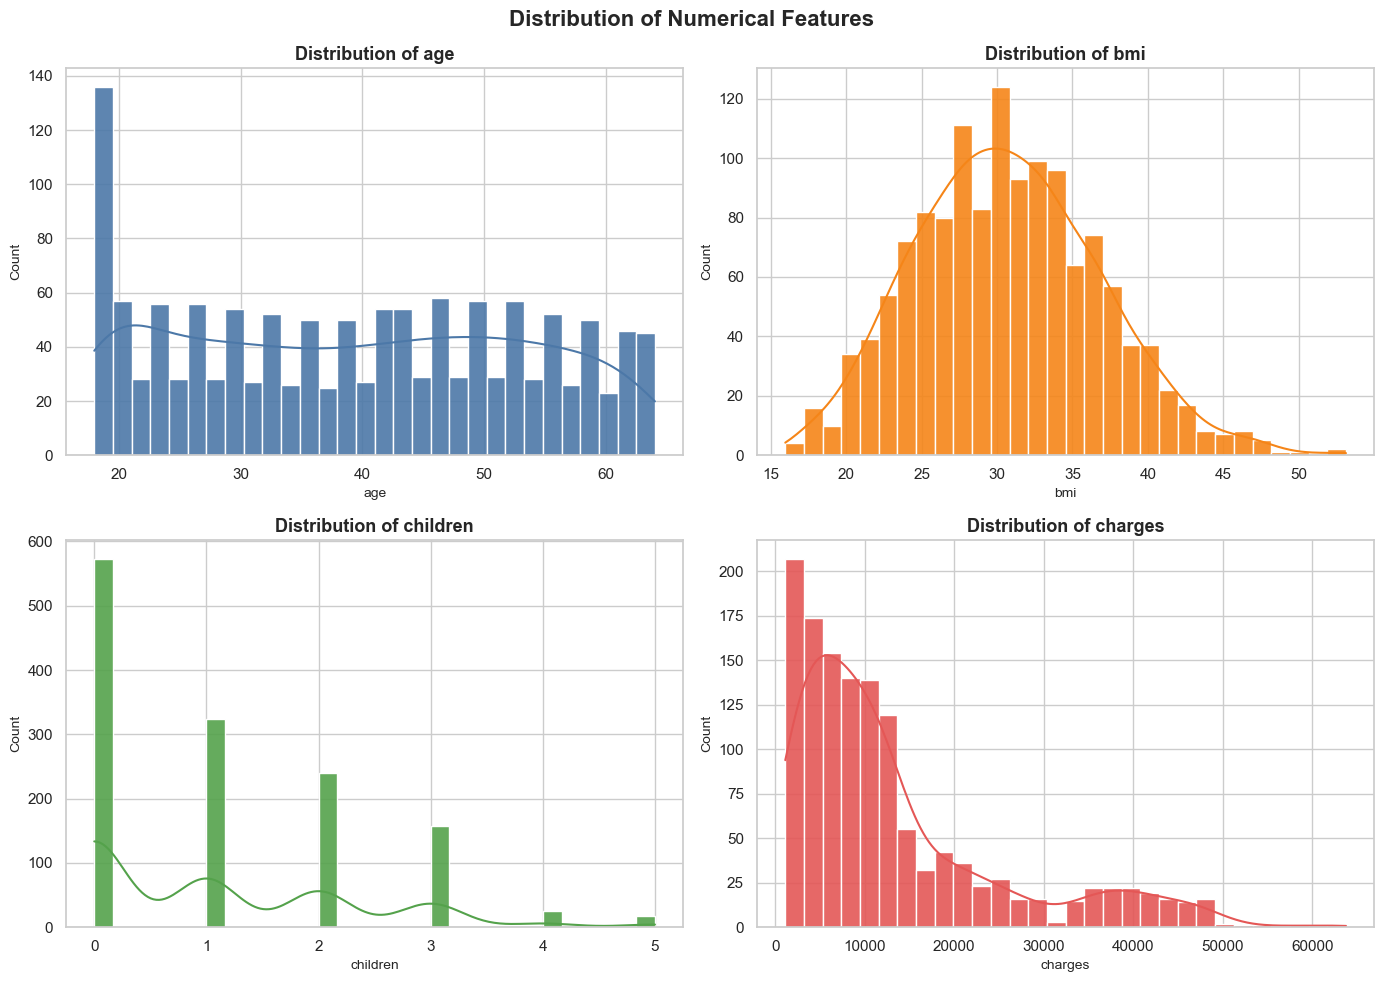

In [12]:
sns.set_theme(style="whitegrid")

# Color palette
palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

num_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(14,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color=palette[i-1],
        edgecolor="white",
        alpha=0.9
    )
    
    plt.title(f"Distribution of {col}", fontsize=13, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Count", fontsize=10)

# Main title
plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights:**

- The numerical features were analyzed using distribution plots.

- The charges variable shows a highly right-skewed distribution, indicating the presence of extreme values and non-normality. This suggests that transformation may be required to improve model performance.

- The bmi feature follows an approximately normal distribution with slight positive skewness, making it suitable for modeling without major transformation.

- The age variable is fairly uniformly distributed, indicating balanced representation across different age groups.

- The children variable is discrete and concentrated at lower values (0–2), showing that most individuals have fewer dependents.

These observations suggest that the charges variable requires transformation (such as log transformation) to improve model performance.

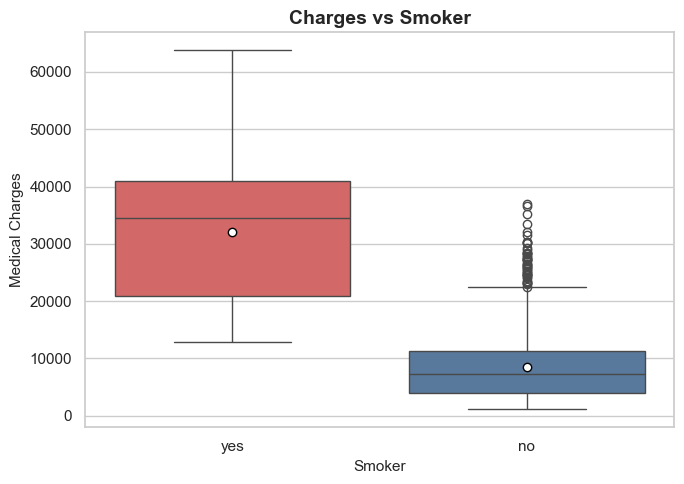

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,5))

sns.boxplot(
    x='smoker',
    y='charges',
    hue='smoker',
    data=df,
    palette=["#E45756", "#4C78A8"],
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black"},
    legend=False
)

plt.title("Charges vs Smoker", fontsize=14, fontweight='bold')
plt.xlabel("Smoker", fontsize=11)
plt.ylabel("Medical Charges", fontsize=11)

plt.tight_layout()
plt.show()

**Insights:**

- The boxplot shows that smokers have significantly higher medical charges compared to non-smokers, indicating a strong impact of smoking on insurance costs.

- The distribution of charges for smokers is also wider, suggesting greater variability in expenses.

- This makes smoker status the most influential variable affecting medical charges in the dataset.

The presence of outliers is also visible, especially for smokers, indicating high medical expenses.

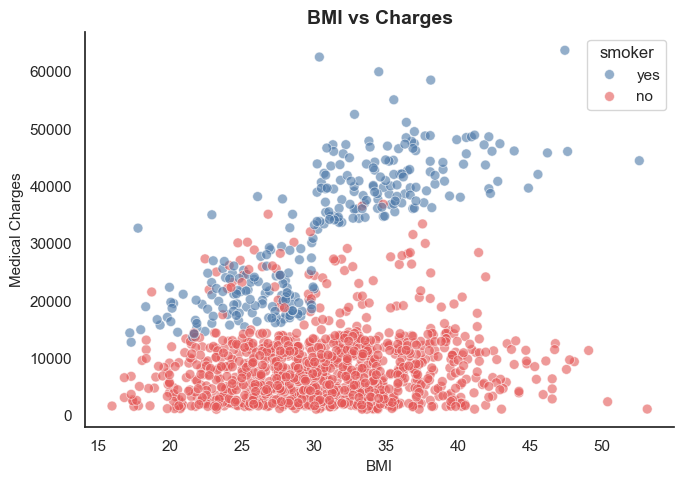

In [14]:
sns.set_theme(style="white")

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='bmi',
    y='charges',
    data=df,
    hue='smoker',
    palette=["#4C78A8", "#E45756"],
    alpha=0.6,
    s=50
)

plt.title("BMI vs Charges", fontsize=14, fontweight='bold')
plt.xlabel("BMI", fontsize=11)
plt.ylabel("Medical Charges", fontsize=11)

sns.despine()  # remove top/right borders

plt.tight_layout()
plt.show()

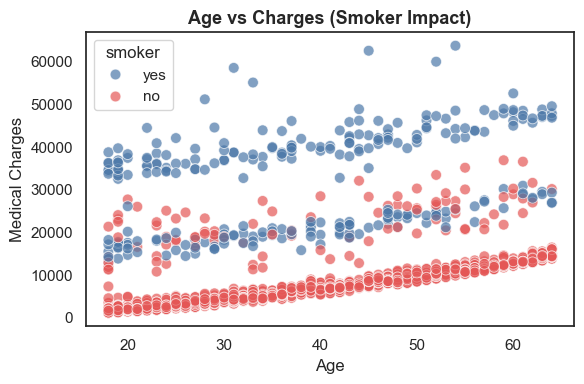

In [15]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='age',
    y='charges',
    data=df,
    hue='smoker',
    palette=["#4C78A8", "#E45756"],
    alpha=0.7,
    s=60
)

plt.title("Age vs Charges (Smoker Impact)", fontsize=13, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.tight_layout()
plt.show()

**Insights:**

- The scatter plots show that both BMI and age have a positive relationship with medical charges.

- In the BMI vs charges plot, higher BMI values tend to be associated with higher charges, although the separation between smoker and non-smoker groups indicates that smoking significantly increases medical charges.

- The age vs charges plot shows a clearer upward trend, indicating that medical expenses generally increase with age.

- The presence of distinct clusters in both plots suggests that other factors, such as smoking status, also significantly influence medical charges.

The pattern shows multiple bands, suggesting that other factors such as smoking also influence charges.

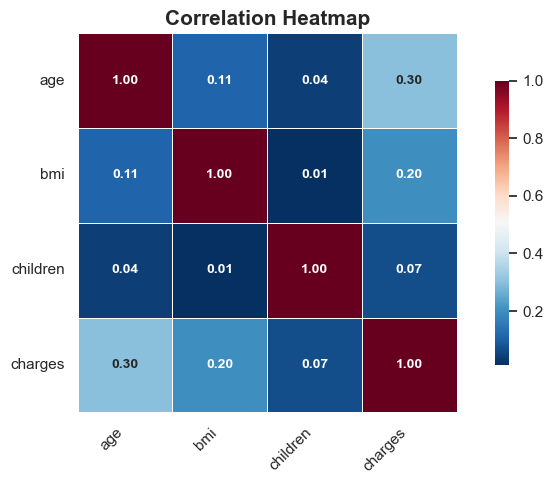

In [16]:
# Create correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
sns.set_theme(style="white")

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size":10, "weight":"bold"}
)

plt.title("Correlation Heatmap", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

**Insights:**

- The correlation heatmap shows that age and BMI have a moderate positive relationship with medical charges, while the number of children has a weak relationship.

- The log-transformed charges variable (charges_log) shows a strong correlation with the original charges, confirming the effectiveness of the transformation.

- No strong correlation is observed among independent variables, indicating the absence of multicollinearity.

- The absence of strong correlation between features indicates low multicollinearity, which is beneficial for modeling.

In [17]:
# Feature correlation with target
df.corr(numeric_only=True)['charges'].sort_values(ascending=False)

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64

**Insights:**
  - The correlation values confirm that age and BMI have a moderate positive relationship with charges, while children has a weak impact. This supports earlier EDA findings.

**EDA Insight Summary**

- **The exploratory data analysis revealed several important patterns in the dataset.**

- **The target variable (charges) is highly right-skewed, indicating the presence of extreme values and the need for transformation to improve model performance.**

- **Smoking status is the most influential factor affecting medical charges, with smokers incurring significantly higher costs than non-smokers.**

- **BMI shows a positive relationship with charges, where higher BMI values tend to increase medical expenses.**

- **Age is moderately correlated with charges, indicating that older individuals generally have higher medical costs.**

- **The children feature has minimal impact on charges and shows a discrete distribution.**

- **Categorical variables such as sex and region are fairly balanced and do not show strong direct influence on the target variable.**

- **No strong multicollinearity was observed among numerical features, making them suitable for modeling.**

**Overall, smoking status, BMI, and age are the most significant predictors of medical insurance charges, and appropriate preprocessing such as log transformation is required due to skewness in the target variable.**

### 3. Missing Values & Outlier Treatment
- Check for missing values and treat them if any
- Check if there are anu outliers.


In [18]:
# Missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

**Insights:**
- No missing values were found in the dataset, indicating that the data is complete and no imputation is required.

In [19]:
# Outlier detection using IQR
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


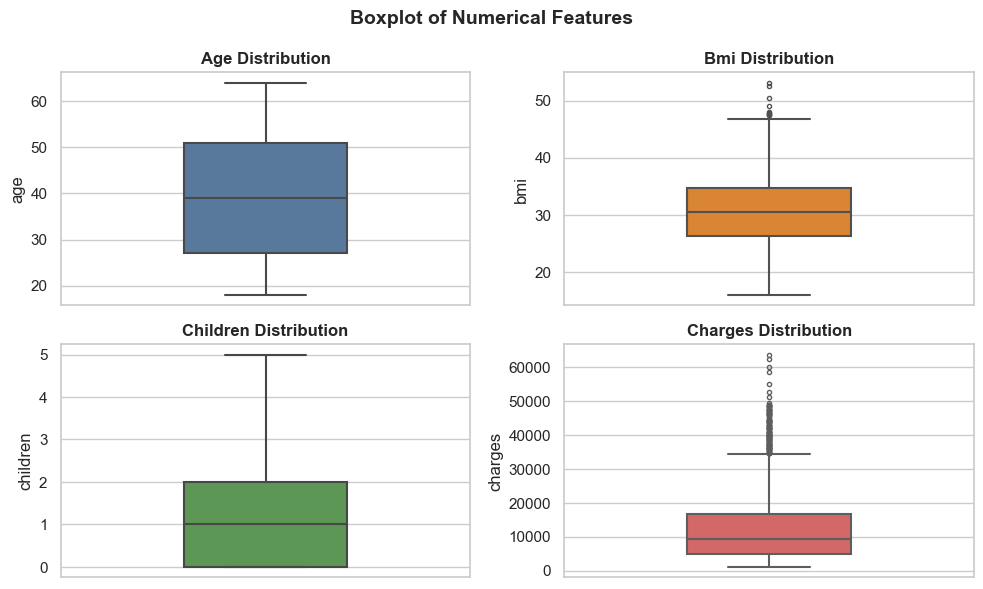

In [20]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    
    sns.boxplot(
        y=df[col],
        color=palette[i-1],
        linewidth=1.5,
        fliersize=3,
        width=0.4
    )
    
    plt.title(f"{col.capitalize()} Distribution", fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel(col)

# Main title
plt.suptitle("Boxplot of Numerical Features", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights:**

- Outlier analysis using the IQR method and boxplots shows that the charges variable contains a significant number of outliers, while bmi has a few mild outliers and age and children do not show significant outliers.

- The outliers in the charges variable were retained, as they represent real-world high medical expenses and are important for model learning.

- To reduce the effect of these extreme values and improve model performance, a log transformation will be applied to the charges variable in the preprocessing step.

### 4.Feature Engineering & Preprocessing
   - Encode categorical variables (sex, smoker, region)
   - Feature scaling for numerical values (StandardScaler / MinMaxScaler)
   - Check for skewness and treat it if required.


In [21]:
df[['age', 'bmi', 'children', 'charges']].skew()

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64

In [22]:
df['charges_log'] = np.log1p(df['charges'])
df['charges_log'].skew()

np.float64(-0.08955835073325419)

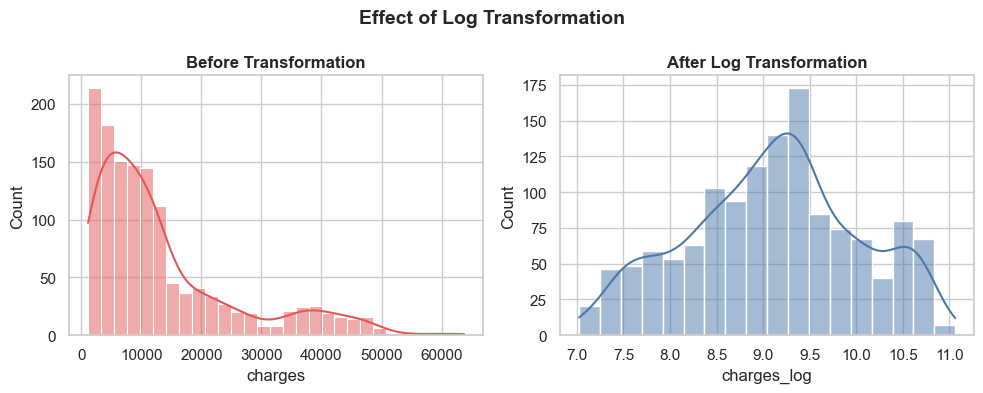

In [23]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,4))

# Before
plt.subplot(1,2,1)
sns.histplot(df['charges'], kde=True, color="#E45756", edgecolor="white")
plt.title("Before Transformation", fontsize=12, fontweight='bold')

# After
plt.subplot(1,2,2)
sns.histplot(df['charges_log'], kde=True, color="#4C78A8", edgecolor="white")
plt.title("After Log Transformation", fontsize=12, fontweight='bold')

plt.suptitle("Effect of Log Transformation", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights:**
- The target variable (charges) was highly right-skewed. A log transformation using log1p() was applied to normalize the distribution, which helps improve model performance and reduces the impact of extreme values.

In [24]:
X = df.drop(['charges', 'charges_log'], axis=1)
y = df['charges_log']

X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Copy to avoid warning
X_train = X_train.copy()
X_test = X_test.copy()

# Scaling
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Insights:**

- The target variable (charges) showed high positive skewness, so a log transformation was applied using the natural logarithm to normalize its distribution and reduce the effect of extreme values.

- Categorical variables such as sex, smoker, and region were encoded using One-Hot Encoding to convert them into numerical format.

- The dataset was split into training and testing sets to ensure proper model evaluation.

- Feature scaling was applied using StandardScaler to normalize numerical features such as age, bmi, and children, ensuring they are on the same scale and improving the performance of models like SVR and KNN.

Overall, these preprocessing steps prepared the dataset effectively for machine learning modeling.

### 5. Model Building: Try Multiple Regressors

- Use all the regression-based models to train and test the data:
    - Linear Regression
    - Decision Tree Regressor
    - Random Forest Regressor
    - SVR
    - KNN
    - Ensemble Learning methods

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42), 
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, mse, rmse, r2])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"])
results_df.sort_values(by="R2 Score", ascending=False)

# Automatically select best model
best_model_name = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: SVR


**Insights:**

- Multiple regression models were trained and evaluated using MAE, RMSE, and R² score.

- Among all models, SVR performed the best with the highest R² score, indicating strong predictive performance.

- Gradient Boosting and Random Forest also performed well, showing stable and reliable results.

- Linear Regression performed moderately, while KNN showed lower performance compared to other models.

- Decision Tree performed the worst, likely due to overfitting.

Overall, SVR is selected as the best model for this dataset as it provides the most accurate predictions.

### 6. Model Evaluation & Overfitting Check
- Use metrics:
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - R² Score
    - Adjusted R² Score
    - Compare performance on both datasets (Training and testing) to detect overfitting


In [26]:
# Choose best model
best_model = SVR()
best_model.fit(X_train, y_train)

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Metrics (Train)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Metrics (Test)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

#Adjusted R²
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

print("Adjusted R2:", adj_r2)
print("Train R2:", r2_train)
print("Test R2:", r2_test)
print()
print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

Adjusted R2: 0.8764420377408071
Train R2: 0.8282938012100878
Test R2: 0.880144148969547

Train RMSE: 0.3755762410907479
Test RMSE: 0.3334858258555011


In [27]:
#overfitting checking across all models
for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    print(f"{name}: Train R2 = {train_score:.3f}, Test R2 = {test_score:.3f}")

Linear Regression: Train R2 = 0.750, Test R2 = 0.829
Decision Tree: Train R2 = 1.000, Test R2 = 0.699
Random Forest: Train R2 = 0.970, Test R2 = 0.842
Gradient Boosting: Train R2 = 0.874, Test R2 = 0.878
SVR: Train R2 = 0.828, Test R2 = 0.880
KNN: Train R2 = 0.805, Test R2 = 0.733


**Insights:**

- The model was evaluated using MAE, MSE, RMSE, R² score, and Adjusted R².

- The Train R² (0.828) and Test R² (0.880) values for SVR are very close, indicating that the model is not overfitting and generalizes well to unseen data.

- The Adjusted R² score (0.876) confirms that the model performance remains strong even after considering the number of features.

- The RMSE values for training and testing are also similar, indicating consistent prediction accuracy.

- When comparing all models, SVR performed the best, followed by Gradient Boosting and Random Forest.

- Decision Tree clearly overfits the data, as it shows a very high training score but a much lower test score.

Overall, the model is stable, accurate, and reliable for predicting medical insurance charges.

### 7. Hyperparameter Tuning

- Use GridSearchCV or RandomizedSearchCV to optimize the best-performing models
- Document best parameters and improvement in performance


In [28]:
svr = SVR()
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1]
}

# 1. GridSearchCV
grid = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_svr = grid.best_estimator_
y_pred = best_svr.predict(X_test)

print("\n--- GridSearchCV Result ---")
print("Best Parameters:", grid.best_params_)
print("R2 Score:", r2_score(y_test, y_pred))

# 2. RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)

print("\n--- RandomizedSearchCV Result ---")
print("Best Parameters:", random_search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred_random))


--- GridSearchCV Result ---
Best Parameters: {'C': 10, 'epsilon': 0.01, 'kernel': 'rbf'}
R2 Score: 0.8760343608038816

--- RandomizedSearchCV Result ---
Best Parameters: {'kernel': 'rbf', 'epsilon': 0.1, 'C': 1}
R2 Score: 0.880144148969547


In [29]:
# BEFORE TUNING
svr_default = SVR()
svr_default.fit(X_train, y_train)

y_pred_default = svr_default.predict(X_test)
r2_before = r2_score(y_test, y_pred_default)

print("Before Tuning R2:", r2_before)

# AFTER TUNING
y_pred_tuned = best_random_model.predict(X_test)
r2_after = r2_score(y_test, y_pred_tuned)

print("After Tuning R2:", r2_after)

Before Tuning R2: 0.880144148969547
After Tuning R2: 0.880144148969547


**Insights:**

- Hyperparameter tuning was performed using both GridSearchCV and RandomizedSearchCV on the SVR model.
  
- RandomizedSearchCV achieved a slightly higher R² score compared to GridSearchCV and was selected as the best-performing model.

- Before tuning, the model achieved an R² score of 0.88. After tuning, the performance remained approximately the same, indicating that the default model was already well-optimized.

- This demonstrates that hyperparameter tuning helps identify optimal parameter combinations, although it may not always significantly improve performance.

### 8. Model Comparison Table

In [30]:
comparison_results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    overfit = "Yes" if (train_r2 - test_r2) > 0.05 else "No"
    
    comparison_results.append([
        name, train_rmse, test_rmse, train_r2, test_r2, overfit
    ])

comparison_df = pd.DataFrame(comparison_results, columns=[
    "Model", "Train RMSE", "Test RMSE", "Train R2", "Test R2", "Overfitting"
])

comparison_df = comparison_df.sort_values(by="Test R2", ascending=False).round(3)

# Mark best model automatically
best_model_name = comparison_df.iloc[0]["Model"]

comparison_df["Best Model"] = comparison_df["Model"].apply(
    lambda x: "Yes" if x == best_model_name else "No"
)

comparison_df

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting,Best Model
4,SVR,0.376,0.333,0.828,0.880,No,Yes
3,Gradient Boosting,0.322,0.337,0.874,0.878,No,No
2,Random Forest,0.157,0.383,0.970,0.842,Yes,No
0,Linear Regression,0.453,0.398,0.750,0.829,No,No
5,KNN,0.400,0.498,0.805,0.733,Yes,No
1,Decision Tree,0.000,0.528,1.000,0.699,Yes,No


**Insights:**

- The model comparison shows that SVR achieved the highest test R² score, indicating the best performance among all models.

- Gradient Boosting also performed well with balanced training and testing scores, showing good generalization.

- Random Forest and KNN show overfitting, as their training performance is significantly higher than testing performance.

- Linear Regression shows stable performance but lower accuracy, indicating a simpler model.

- Decision Tree shows strong overfitting due to a very large difference between training and testing scores.

Overall, SVR is selected as the best model because it provides the highest accuracy with no significant overfitting.

**Final Conclusion:**

- This project developed multiple regression models to predict medical insurance charges.

**Key Insights:**
- Target variable (charges) was highly right-skewed → log transformation improved distribution
- Smoking status is the most influential feature
- Age and BMI have strong positive relationships with charges

**Model Performance:**
- SVR achieved the highest Test R² score (0.880)
- Gradient Boosting also performed strongly with stable results
- Decision Tree showed overfitting

**Overfitting Check:**
- Train and Test scores are very close → good generalization

**Business Impact:**
- Helps identify high-risk individuals (especially smokers)
- Enables better premium pricing strategies
- Supports cost prediction and risk management

**Final Model:**
SVR is selected due to highest accuracy and strong generalization ability.

### Streamlit App Code (For Deployment and Review)

In [31]:
import pickle

# Use your trained model
final_model = best_model   

# Save files
pickle.dump(final_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("Done! Files saved.")

Done! Files saved.


In [ ]:
# ================================
# STREAMLIT APP (FINAL)
# ================================

import streamlit as st
import pandas as pd
import numpy as np
import pickle

# PAGE CONFIG
st.set_page_config(
    page_title="Insurance Predictor",
    page_icon="💰",
    layout="centered"
)

# STYLE
st.markdown("""
<style>
[data-testid="stAppViewContainer"] {
    background-image: url("https://images.unsplash.com/photo-1576091160550-2173dba999ef");
    background-size: cover;
    background-position: center;
    background-attachment: fixed;
}

.block-container {
    background-color: rgba(255,255,255,0.88);
    padding: 2rem;
    border-radius: 12px;
    margin-top: 20px;
}

section[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #2C3E50, #4CA1AF);
    color: white;
}

[data-testid="stSliderTickBarMin"],
[data-testid="stSliderTickBarMax"] {
    display: none;
}

[data-baseweb="slider"] div[role="slider"] {
    width: 10px !important;
    height: 10px !important;
}

.stButton>button {
    width: 100%;
    border-radius: 10px;
    height: 3em;
    font-size: 16px;
    font-weight: bold;
    background: #2c3e50;
    color: white;
    border: none;
}

.result-box {
    padding: 20px;
    border-radius: 12px;
    background: white;
    color: #2c3e50;
    text-align: center;
    font-size: 26px;
    font-weight: bold;
    margin-top: 20px;
    box-shadow: 0px 4px 20px rgba(0,0,0,0.2);
}
</style>
""", unsafe_allow_html=True)

# LOAD FILES
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

# HEADER
col1, col2 = st.columns([1, 4])

with col1:
    st.image("https://cdn-icons-png.flaticon.com/512/3135/3135715.png", width=70)

with col2:
    st.markdown("""
    <h1 style='color:#2C3E50;'>Medical Insurance Cost Predictor</h1>
    <p style='color:#555;'>Smart AI-powered estimation for accurate insurance planning</p>
    """, unsafe_allow_html=True)

# SIDEBAR
st.sidebar.markdown("## 🧾 User Input Panel")
st.sidebar.markdown(
    "<p style='font-size:13px; color:#e0e0e0;'>Enter details to estimate insurance cost</p>",
    unsafe_allow_html=True
)

st.sidebar.markdown("---")

age = st.sidebar.slider("Age", 18, 100, 25)
bmi = st.sidebar.slider("BMI", 10.0, 50.0, 25.0)
children = st.sidebar.selectbox("Children", [0,1,2,3,4,5])
sex = st.sidebar.selectbox("Sex", ["male","female"])
smoker = st.sidebar.selectbox("Smoker", ["yes","no"])
region = st.sidebar.selectbox("Region", ["northwest","northeast","southeast","southwest"])

st.sidebar.markdown("---")
st.sidebar.write("Copyright 2026 Heramba Kakati")

# INPUT
input_data = pd.DataFrame({
    'age':[age],
    'bmi':[bmi],
    'children':[children],
    'sex':[sex],
    'smoker':[smoker],
    'region':[region]
})

input_data = pd.get_dummies(input_data)
input_data = input_data.reindex(columns=columns, fill_value=0)

input_data[['age','bmi','children']] = scaler.transform(input_data[['age','bmi','children']])

# PREDICT
if st.button("Predict Insurance Cost"):
    prediction = model.predict(input_data)
    prediction = np.expm1(prediction)

    st.markdown(f"""
    <div class="result-box">
        ₹ {prediction[0]:,.2f}
    </div>
    """, unsafe_allow_html=True)